In [ ]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [ ]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN rtParent.title like '% Tap' and smt.group_id is not null THEN rtParent.title ELSE 'No Gesture' END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title like '% Tap' and smt.group_id is not null THEN 1 ELSE 0 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
WHERE is_gesture = 1
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [ ]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [ ]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [ ]:
# Augment the data in a way, that you copy all rows with their columns, only change the order of the touch_X_* columns randomly, also append a unique suffix to the id fields, group_id, session_task_id, participant_id, so that they are unique in the new dataset
def augment_data(df, n_augmentations=1):
    augmented_dfs = []
    
    for i in range(n_augmentations):
        df_aug = df.copy()
        
        # Shuffle touch columns
        shuffled_indices = np.random.permutation(5) + 1  # Touch indices from 1 to 5
        for j, new_idx in enumerate(shuffled_indices, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']
        
        # Append unique suffix to id fields
        df_aug['id'] = df_aug['id'].astype(str) + f'_aug{i}'
        df_aug['group_id'] = df_aug['group_id'].astype(str) + f'_aug{i}'
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + f'_aug{i}'
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + f'_aug{i}'
        
        augmented_dfs.append(df_aug)
    
    return pd.concat([df] + augmented_dfs, ignore_index=True)

def augment_data_all_permutations(df, limit=None):
    augmented_dfs = []

    # All 5! = 120 permutations of touch indices 1..5
    permutations = list(itertools.permutations(range(1, 6)))

    for i, perm in enumerate(permutations):
        if limit is not None and i >= limit:
            break

        df_aug = df.copy()

        # Reorder touch columns according to permutation
        for j, new_idx in enumerate(perm, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']

        # Append unique suffix to id fields
        suffix = f'_perm{i}'
        df_aug['id'] = df_aug['id'].astype(str) + suffix
        df_aug['group_id'] = df_aug['group_id'].astype(str) + suffix
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + suffix
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + suffix

        augmented_dfs.append(df_aug)

    # Original + all permutations
    return pd.concat([df] + augmented_dfs, ignore_index=True)

In [ ]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [ ]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
Two-Finger Opposite Double Tap    3010
Two-Finger Double Tap             3001
Double Tap                        2784
Two-Finger Opposite Tap           1719
Two-Finger Tap                    1646
Single Tap                        1407
Name: count, dtype: int64

In [ ]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [ ]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    1642
6331fbd1-76bb-48d6-92a2-80a55a70d134    1608
696b4743-9d39-4fb1-8271-90e7d48652af    1361
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    1749
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    1764
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    2061
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    1713
fdd02af8-c764-43ba-8247-c612f85568b4    1669
dtype: int64

In [ ]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel']

In [ ]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

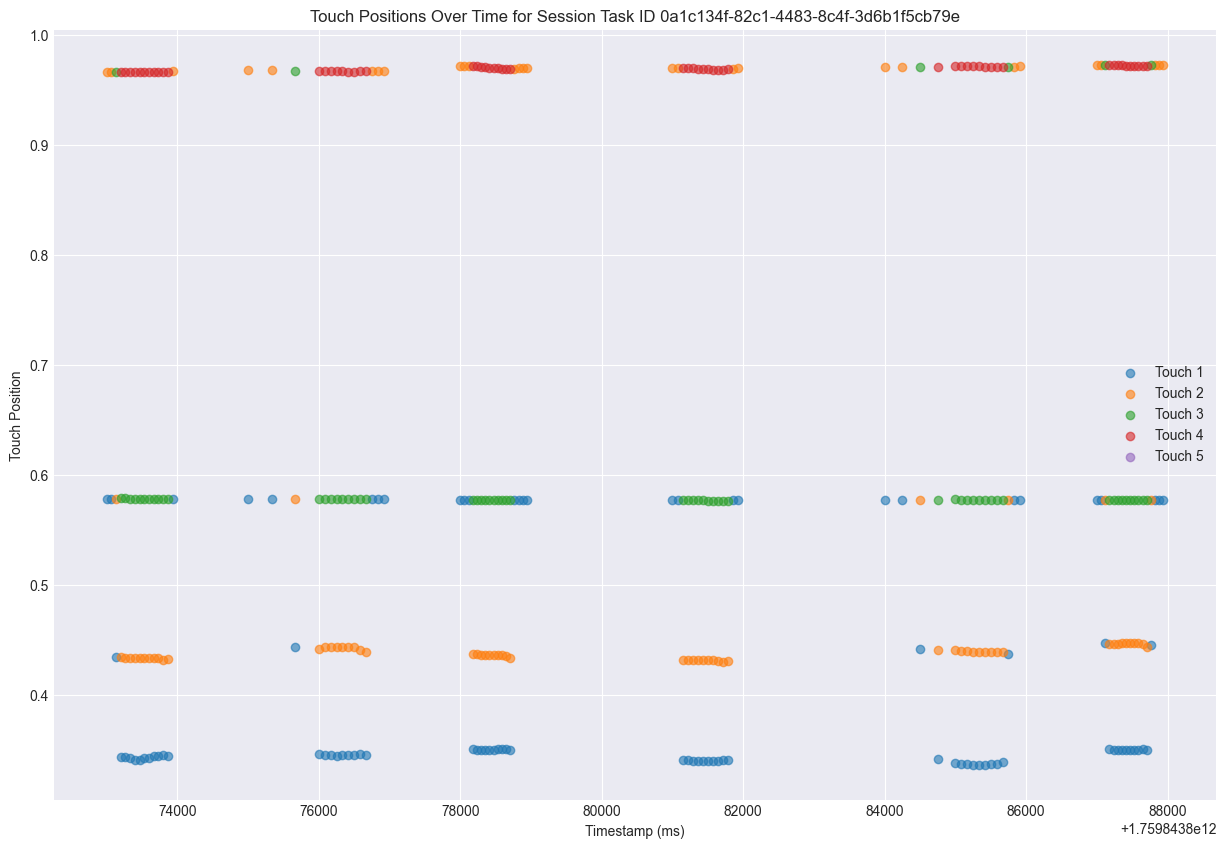

In [ ]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [ ]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


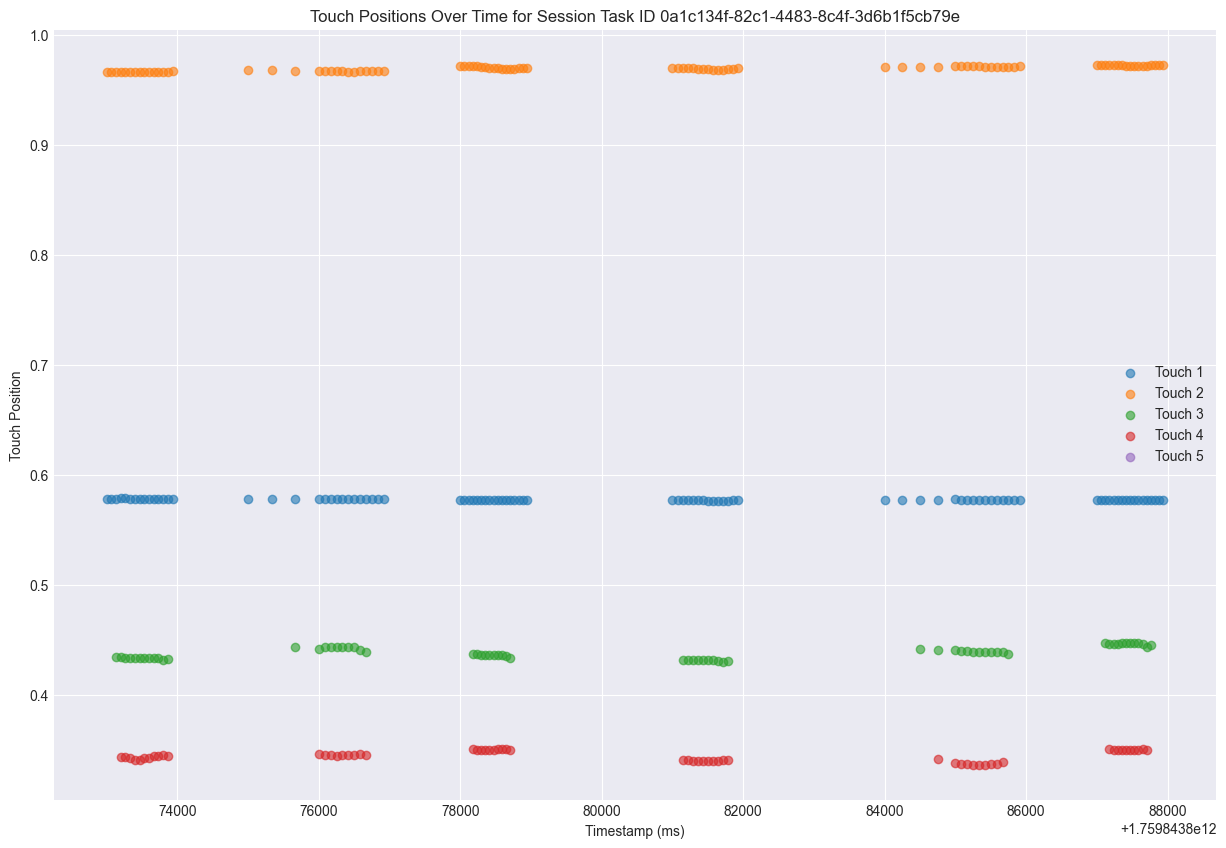

In [ ]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [ ]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
dtype: int64

In [ ]:
# Print the LABEL_COLUMN counts
print(df_clean[LABEL_COLUMN].value_counts())

parent_gesture
Two-Finger Opposite Double Tap    3010
Two-Finger Double Tap             3001
Double Tap                        2784
Two-Finger Opposite Tap           1719
Two-Finger Tap                    1646
Single Tap                        1407
Name: count, dtype: int64


In [ ]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=5, long_smoothing_window=60):
    # Create empty feature dataframe
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    # Instant Features
    pressure_cols = [f"touch_{i+1}_pressure" for i in range(5)]
    active_touches = (feature_df[pressure_cols] > 0)
    # add_feature("num_active_touches", active_touches.sum(axis=1))

    # Distances for each finger in the rolling window to each other finger
    for (i, j) in combinations(range(1, 6), 2):
        pos_i = feature_df[f'touch_{i}_position']
        pos_j = feature_df[f'touch_{j}_position']
        p_i = feature_df[f"touch_{i}_pressure"]
        p_j = feature_df[f"touch_{j}_pressure"]

        # distance only when both fingers are active; else 0 (or np.nan if you prefer)
        dist_col = f"dist_{i}_{j}"
        dist = short_dist(pos_i, pos_j)
        both_touching = (p_i > 0) & (p_j > 0)
        add_feature(dist_col, dist)
        add_feature(f"{dist_col}_both_touching", both_touching.astype(int))

        # Calculate a flag if both fingers are active in the long smoothing window
        # long_both_touching = both_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f"{dist_col}_long_both_active", long_both_touching.astype(int))

        # Calculate a flag if both have moved
        # min_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_i = (max_long_rolling_i - min_long_rolling_i) > TOUCH_MOVE_THRESHOLD
        # min_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_j = (max_long_rolling_j - min_long_rolling_j) > TOUCH_MOVE_THRESHOLD
        # both_moved = has_moved_i & has_moved_j
        # add_feature(f"{dist_col}_both_moved_longterm", both_moved.astype(int))

    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        # velocity calculation
        pos_diff = feature_df[position_col].diff().fillna(0)
        time_diff = feature_df[TIMESTAMP_COLUMN].diff().fillna(1) / 1000.0  # convert ms to s
        velocity = pos_diff / time_diff
        add_feature(f'touch_{touch_num}_position_velocity', velocity)

        # acceleration calculation
        velocity_diff = velocity.diff().fillna(0)
        acceleration = velocity_diff / time_diff
        add_feature(f'touch_{touch_num}_position_acceleration', acceleration)

        # split to rotational position into x and y components for smoothing
        # add_feature(f'touch_{touch_num}_pos_x', np.cos(2 * np.pi * feature_df[position_col]))
        # add_feature(f'touch_{touch_num}_pos_y', np.sin(2 * np.pi * feature_df[position_col]))

        # Get the min and max distance to all other fingers
        other_positions = [f'touch_{i}_position' for i in range(1, 6) if i != touch_num]
        if other_positions:
            for i in range(1, 6):
                if i == touch_num:
                    continue
                other_pos_col = f'touch_{i}_position'
                other_press_col = f'touch_{i}_pressure'
                dist_to_other = short_dist(feature_df[position_col], feature_df[other_pos_col])
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}', dist_to_other)
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}_when_both_active', 
                            dist_to_other * ((feature_df[pressure_col] > 0) & (feature_df[other_press_col] > 0)).astype(int)
                           )
                

        is_touching = (feature_df[pressure_col] > 0)
        add_feature(f'touch_{touch_num}_is_active', is_touching.astype(int))
        is_active_smoothed = is_touching.rolling(window=smoothing_window, min_periods=1).mean()
        # add_feature(f'touch_{touch_num}_is_active_smoothed', is_active_smoothed)

        # Add a flag, whether a finger touched and released and touched again in the smoothing window
        reactivation = (~is_touching.shift(1, fill_value=False)) & is_touching
        touch_before = is_touching.rolling(smoothing_window).max().astype(bool)
        reactivation_in_window = reactivation.rolling(smoothing_window).max().astype(bool)
        has_reactivated = (touch_before & reactivation_in_window)
        # add_feature(f'touch_{touch_num}_has_reactivated', has_reactivated.astype(int))
        # add_feature(f'touch_{touch_num}_num_reactivations', reactivation.rolling(long_smoothing_window).sum().fillna(0))

        min_long_rolling_pos = feature_df[position_col].rolling(window=long_smoothing_window, min_periods=1).min()
        max_long_rolling_pos = feature_df[position_col].rolling(window=long_smoothing_window, min_periods=1).max()
        has_moved = (max_long_rolling_pos - min_long_rolling_pos) > TOUCH_MOVE_THRESHOLD
        # add_feature(f'touch_{touch_num}_has_moved_longterm', has_moved.astype(int))

        long_touch = is_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f'touch_{touch_num}_long_touch', long_touch.astype(int))

        # Add flag if the touch is active or not, it is active if np.any(is_touching) and (has_moved or not is_continuous_touch)
        is_active_touch = is_touching & (has_moved | (~long_touch))
        # add_feature(f'touch_{touch_num}_is_active_touch', is_active_touch.astype(int))

        # 1. Calculate the 'Rising Edge' (The moment a finger hits the glass)
        rising_edge = (feature_df[pressure_col] > 0) & (feature_df[pressure_col].shift(1) <= 0)
        falling_edge = (feature_df[pressure_col] <= 0) & (feature_df[pressure_col].shift(1) > 0)

        add_feature(f'{touch_num}_rising_edge', rising_edge.astype(int))
        add_feature(f'{touch_num}_falling_edge', falling_edge.astype(int))

        # 2. Count rising edges in a wider 'gesture window' (e.g., 500ms)
        # This directly tells the model: "Two taps just happened very close together"
        add_feature(f'{touch_num}_tap_count', falling_edge.rolling(window=long_smoothing_window, min_periods=1).sum())

        pressure = feature_df[pressure_col]
        pressure_detrended = pressure - pressure.rolling(window=smoothing_window, min_periods=1).mean()
        short_time_energy = pressure_detrended.pow(2).rolling(window=smoothing_window, min_periods=1).sum()
        energy_th = short_time_energy.rolling(window=long_smoothing_window, min_periods=1).mean() + 2 * short_time_energy.rolling(window=long_smoothing_window, min_periods=1).std()
        energy_peak = (short_time_energy > energy_th) & (short_time_energy.shift(1) <= energy_th.shift(1))
        # add_feature(f'{touch_num}_energy_peak', energy_peak.astype(int).rolling(window=long_smoothing_window, min_periods=1).sum())

        # 3. Calculate the duration of the current 'touch'
        # If this is too long, it's a 'long press', not part of a double tap
        is_touching = (feature_df[pressure_col] > 0)
        touch_duration = is_touching.groupby((is_touching != is_touching.shift()).cumsum()).cumsum()
        # add_feature(f'{touch_num}_active_duration', touch_duration * is_touching)

        add_feature(f'{position_col}_mean', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_mean', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        # add_feature(f'{channel_col}_mean', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        # add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))

    # add_feature("num_active_touches_mean", feature_df["num_active_touches"]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .mean())
    # add_feature("num_active_touches_max", feature_df["num_active_touches"]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .max())
    active_touches_contrast = active_touches - active_touches.rolling(window=2, min_periods=1).median()
    # add_feature("num_active_touches_contrast", active_touches_contrast.sum(axis=1))
    
    # dist_cols = [c for c in feature_df.columns if c.startswith("dist_")]
    # for col in dist_cols:
    #     add_feature(f"{col}_rollmean", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .mean())
    #     add_feature(f"{col}_rollstd", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .std()
    #         .fillna(0.0))

    return feature_df, additional_features

In [ ]:
def get_column_names(feature_columns):
    return feature_columns
    # return SENSOR_COLUMNS
    # return SENSOR_COLUMNS + feature_columns

In [ ]:
df_permutated = augment_data_all_permutations(df_clean, limit=50)
# df_permutated = df_clean.copy()

In [ ]:
df, additional_columns = create_feature_df(df_permutated)
feature_columns = get_column_names(additional_columns)

df = df.sort_values(
    by=["participant_id", "session_task_id", TIMESTAMP_COLUMN]
).reset_index(drop=True)

gesture_block = 0
prev_pid = None
prev_sid = None
prev_is_gesture = None
prev_label = None
blocks = []
prev_group_id = None

for i, row in df.iterrows():
    pid = row["participant_id"]
    sid = row["session_task_id"]
    is_g = row["is_gesture"]
    lab = row[LABEL_COLUMN]
    group_id = row["group_id"]

    # New block when:
    # - participant or session changes
    # - or gesture/background state changes
    # - or gesture label changes
    if (
        pid != prev_pid or
        sid != prev_sid or
        is_g != prev_is_gesture or
        lab != prev_label or
        group_id != prev_group_id
    ):
        gesture_block += 1

    blocks.append(gesture_block)

    prev_pid = pid
    prev_sid = sid
    prev_is_gesture = is_g
    prev_label = lab
    prev_group_id = group_id

df["gesture_block"] = blocks

In [ ]:
additional_columns

['dist_1_2',
 'dist_1_2_both_touching',
 'dist_1_3',
 'dist_1_3_both_touching',
 'dist_1_4',
 'dist_1_4_both_touching',
 'dist_1_5',
 'dist_1_5_both_touching',
 'dist_2_3',
 'dist_2_3_both_touching',
 'dist_2_4',
 'dist_2_4_both_touching',
 'dist_2_5',
 'dist_2_5_both_touching',
 'dist_3_4',
 'dist_3_4_both_touching',
 'dist_3_5',
 'dist_3_5_both_touching',
 'dist_4_5',
 'dist_4_5_both_touching',
 'touch_1_position_velocity',
 'touch_1_position_acceleration',
 'touch_1_dist_to_touch_2_position',
 'touch_1_dist_to_touch_2_position_when_both_active',
 'touch_1_dist_to_touch_3_position',
 'touch_1_dist_to_touch_3_position_when_both_active',
 'touch_1_dist_to_touch_4_position',
 'touch_1_dist_to_touch_4_position_when_both_active',
 'touch_1_dist_to_touch_5_position',
 'touch_1_dist_to_touch_5_position_when_both_active',
 'touch_1_is_active',
 '1_rising_edge',
 '1_falling_edge',
 '1_tap_count',
 'touch_1_position_mean',
 'touch_1_pressure_mean',
 'touch_1_position_diff',
 'touch_1_pressure_

In [ ]:
df.head()

,id,session_task_id,session_task_row_index,timestamp,timestamp_ms,button_pressed,motor_angle,gesture,parent_gesture,participant_id,is_gesture,group_id,estimated_timestamp,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,active_ids,dist_1_2,dist_1_2_both_touching,dist_1_3,dist_1_3_both_touching,dist_1_4,dist_1_4_both_touching,dist_1_5,dist_1_5_both_touching,dist_2_3,dist_2_3_both_touching,dist_2_4,dist_2_4_both_touching,dist_2_5,dist_2_5_both_touching,dist_3_4,dist_3_4_both_touching,dist_3_5,dist_3_5_both_touching,dist_4_5,dist_4_5_both_touching,touch_1_position_velocity,touch_1_position_acceleration,touch_1_dist_to_touch_2_position,touch_1_dist_to_touch_2_position_when_both_active,touch_1_dist_to_touch_3_position,touch_1_dist_to_touch_3_position_when_both_active,touch_1_dist_to_touch_4_position,touch_1_dist_to_touch_4_position_when_both_active,touch_1_dist_to_touch_5_position,touch_1_dist_to_touch_5_position_when_both_active,touch_1_is_active,1_rising_edge,1_falling_edge,1_tap_count,touch_1_position_mean,touch_1_pressure_mean,touch_1_position_diff,touch_1_pressure_diff,touch_1_position_rollstd,touch_1_pressure_rollstd,touch_2_position_velocity,touch_2_position_acceleration,touch_2_dist_to_touch_1_position,touch_2_dist_to_touch_1_position_when_both_active,touch_2_dist_to_touch_3_position,touch_2_dist_to_touch_3_position_when_both_active,touch_2_dist_to_touch_4_position,touch_2_dist_to_touch_4_position_when_both_active,touch_2_dist_to_touch_5_position,touch_2_dist_to_touch_5_position_when_both_active,touch_2_is_active,2_rising_edge,2_falling_edge,2_tap_count,touch_2_position_mean,touch_2_pressure_mean,touch_2_position_diff,touch_2_pressure_diff,touch_2_position_rollstd,touch_2_pressure_rollstd,touch_3_position_velocity,touch_3_position_acceleration,touch_3_dist_to_touch_1_position,touch_3_dist_to_touch_1_position_when_both_active,touch_3_dist_to_touch_2_position,touch_3_dist_to_touch_2_position_when_both_active,touch_3_dist_to_touch_4_position,touch_3_dist_to_touch_4_position_when_both_active,touch_3_dist_to_touch_5_position,touch_3_dist_to_touch_5_position_when_both_active,touch_3_is_active,3_rising_edge,3_falling_edge,3_tap_count,touch_3_position_mean,touch_3_pressure_mean,touch_3_position_diff,touch_3_pressure_diff,touch_3_position_rollstd,touch_3_pressure_rollstd,touch_4_position_velocity,touch_4_position_acceleration,touch_4_dist_to_touch_1_position,touch_4_dist_to_touch_1_position_when_both_active,touch_4_dist_to_touch_2_position,touch_4_dist_to_touch_2_position_when_both_active,touch_4_dist_to_touch_3_position,touch_4_dist_to_touch_3_position_when_both_active,touch_4_dist_to_touch_5_position,touch_4_dist_to_touch_5_position_when_both_active,touch_4_is_active,4_rising_edge,4_falling_edge,4_tap_count,touch_4_position_mean,touch_4_pressure_mean,touch_4_position_diff,touch_4_pressure_diff,touch_4_position_rollstd,touch_4_pressure_rollstd,touch_5_position_velocity,touch_5_position_acceleration,touch_5_dist_to_touch_1_position,touch_5_dist_to_touch_1_position_when_both_active,touch_5_dist_to_touch_2_position,touch_5_dist_to_touch_2_position_when_both_active,touch_5_dist_to_touch_3_position,touch_5_dist_to_touch_3_position_when_both_active,touch_5_dist_to_touch_4_position,touch_5_dist_to_touch_4_position_when_both_active,touch_5_is_active,5_rising_edge,5_falling_edge,5_tap_count,touch_5_position_mean,touch_5_pressure_mean,touch_5_position_diff,touch_5_pressure_diff,touch_5_position_rollstd,touch_5_pressure_rollstd,gesture_block
0,7ae236df-3b8a-46fe-be4b-fcabf2850ad1,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,639,2025-10-07 13:31:13,1759843873000,0,0.205064,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,03f74f16-3fea-4c43-9979-64c4636df12a,2025-10-07 13:31:13.000000000,0.578513,0.377097,0.4,0.966209,0.8029

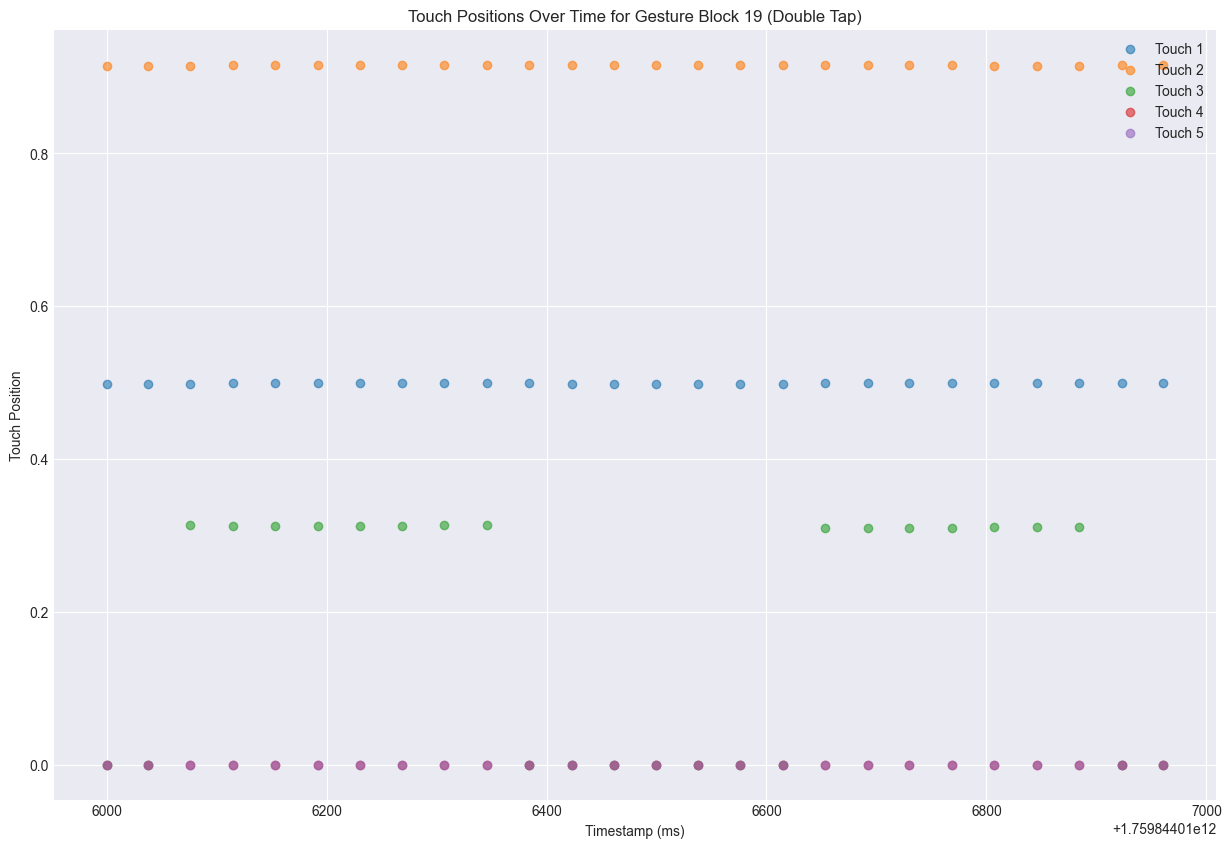

In [ ]:
# draw a graph of the finger positions for the first gesture_block and title it with the parent_gesture

# get the index of the unique gesture block that is a "Tap and Hold" gesture
idx_tap_and_hold = np.where(df["gesture_block"].unique() == df[df[LABEL_COLUMN] == "Double Tap"]["gesture_block"].iloc[1])[0][0]

plt.figure(figsize=(15, 10))
first_gesture_block = df["gesture_block"].unique()[idx_tap_and_hold]
# get the first gesture block, plus some padding before and after
gesture_block_df = df[(df["gesture_block"] == first_gesture_block)]

for touch_num in range(1, 6):
    # plt.scatter(
    #     gesture_block_df["timestamp_ms"], 
    #     gesture_block_df[f"{touch_num}_energy_peak"],
    #     label=f"Dist {touch_num}", 
    #     alpha=0.6
    # )
    plt.scatter(
        gesture_block_df["timestamp_ms"], 
        gesture_block_df[f"touch_{touch_num}_position"],
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Gesture Block {first_gesture_block} ({gesture_block_df[LABEL_COLUMN].iloc[0]})")
plt.legend()
plt.show()

In [ ]:
# Print unique "gesture" column counts
print(df["gesture"].value_counts())

gesture
Two-Finger Double Tap (4 Finger)             83079
Two-Finger Opposite Double Tap (4 Finger)    80478
Two-Finger Opposite Double Tap (All Air)     73032
Double Tap (4 Finger)                        72981
Two-Finger Double Tap (3 Finger)             69972
Double Tap (3 Finger, Luft)                  69003
Two-Finger Opposite Tap (All Air)            46104
Two-Finger Tap (3 Finger)                    42228
Two-Finger Tap (4 Finger)                    41718
Two-Finger Opposite Tap (4 Finger)           41565
Single Tap (3 Finger, Luft)                  40086
Single Tap (4 Finger)                        31671
Name: count, dtype: int64


In [ ]:
gesture_blocks = (
    df[df["is_gesture"] == 1]
    # df
    .groupby(["participant_id", "session_task_id", "group_id", "gesture_block"])
)
print(f"Total gesture blocks (excluding 'No Gesture'): {len(gesture_blocks)}")

Total gesture blocks (excluding 'No Gesture'): 30906


In [ ]:
sequences = []   # list of arrays, each (T_i, D)
labels = []      # list of strings or ints
meta = []

for (pid, sid, group_id, gb), gdf in gesture_blocks:
    # Extract feature matrix for this gesture
    X_seq = gdf[feature_columns].to_numpy(dtype="float32")  # shape (T_i, D)
    if len(X_seq) == 0:
        continue

    sequences.append(X_seq)
    labels.append(gdf[LABEL_COLUMN].iloc[0])  # all rows in block share the same label
    meta.append({
        "group_id": group_id,
        "participant_id": pid,
        "session_task_id": sid,
        "gesture_block": gb,
        "num_samples": len(X_seq),
    })

In [ ]:
# Print the number of sequences and unique labels
print(f"Extracted {len(sequences)} sequences with {len(set(labels))} unique labels.")
# Print the unique labels and their counts
label_counts = pd.Series(labels).value_counts()
print("Label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Extracted 30906 sequences with 6 unique labels.
Label counts:
  Two-Finger Tap: 5559
  Two-Finger Opposite Tap: 5151
  Double Tap: 5151
  Single Tap: 5100
  Two-Finger Opposite Double Tap: 4998
  Two-Finger Double Tap: 4947


In [ ]:
feature_columns

['dist_1_2',
 'dist_1_2_both_touching',
 'dist_1_3',
 'dist_1_3_both_touching',
 'dist_1_4',
 'dist_1_4_both_touching',
 'dist_1_5',
 'dist_1_5_both_touching',
 'dist_2_3',
 'dist_2_3_both_touching',
 'dist_2_4',
 'dist_2_4_both_touching',
 'dist_2_5',
 'dist_2_5_both_touching',
 'dist_3_4',
 'dist_3_4_both_touching',
 'dist_3_5',
 'dist_3_5_both_touching',
 'dist_4_5',
 'dist_4_5_both_touching',
 'touch_1_position_velocity',
 'touch_1_position_acceleration',
 'touch_1_dist_to_touch_2_position',
 'touch_1_dist_to_touch_2_position_when_both_active',
 'touch_1_dist_to_touch_3_position',
 'touch_1_dist_to_touch_3_position_when_both_active',
 'touch_1_dist_to_touch_4_position',
 'touch_1_dist_to_touch_4_position_when_both_active',
 'touch_1_dist_to_touch_5_position',
 'touch_1_dist_to_touch_5_position_when_both_active',
 'touch_1_is_active',
 '1_rising_edge',
 '1_falling_edge',
 '1_tap_count',
 'touch_1_position_mean',
 'touch_1_pressure_mean',
 'touch_1_position_diff',
 'touch_1_pressure_

In [ ]:
# Show the amount of "No Gesture" sequences, that sequence length is smaller or equal to the max length of the other gestures
no_gesture_lengths = [seq.shape[0] for seq, lab in zip(sequences, labels) if lab == "No Gesture"]
min_gesture_lengths = min(no_gesture_lengths) if no_gesture_lengths else 0
max_gesture_lengths = max(no_gesture_lengths) if no_gesture_lengths else 0
print(f"'No Gesture' sequences length: min={min_gesture_lengths}, max={max_gesture_lengths}")

gesture_lengths = [seq.shape[0] for seq, lab in zip(sequences, labels) if lab != "No Gesture"]
min_gesture_lengths = min(gesture_lengths) if gesture_lengths else 0
max_gesture_lengths = max(gesture_lengths) if gesture_lengths else 0
print(f"Gesture sequences length: min={min_gesture_lengths}, max={max_gesture_lengths}")

# Print all labels where the sequence length is greater than 500
long_gesture_labels = [lab for seq, lab in zip(sequences, labels) if seq.shape[0] > 500]
print(f"Labels with sequence length greater than 500: {set(long_gesture_labels)}")

# Draw a graph of all finger positions for the longest sequence that is not a "No Gesture"
max_length = 0
longest_seq = None
for seq, lab, met in zip(sequences, labels, meta):
    if lab != "No Gesture" and seq.shape[0] > max_length:
        max_length = seq.shape[0]
        longest_seq = (seq, lab, met)
if longest_seq:
    seq, lab, met = longest_seq

    # Print the session_task_id
    print(f"Longest sequence session_task_id: {met['session_task_id']}, gesture_block: {met['gesture_block']}, length: {seq.shape[0]}, label: {lab}, group_id: {met['group_id']}")

    # plt.figure(figsize=(15, 10))
    # time_axis = np.arange(seq.shape[0])
    # for touch_num in range(1, 6):
    #     plt.scatter(
    #         time_axis, 
    #         seq[:, feature_columns.index(f"touch_{touch_num}_position")], 
    #         label=f"Touch {touch_num}", 
    #         alpha=0.6
    #     )
    # plt.xlabel("Time Step")
    # plt.ylabel("Touch Position")
    # plt.title(f"Touch Positions Over Time for Longest Sequence ({lab})")
    # plt.legend()
    # plt.show()

'No Gesture' sequences length: min=0, max=0
Gesture sequences length: min=8, max=55
Labels with sequence length greater than 500: set()
Longest sequence session_task_id: b060f668-08fc-4e5a-97f0-ed47f34acdd4, gesture_block: 18978, length: 55, label: Two-Finger Double Tap, group_id: 383b1bee-e378-475b-8c8d-3ced18587627


In [ ]:
# Count the number of sequences with No Gesture, that are longer than the max length of the other gestures
no_gesture_long_sequences = [
    (seq, lab) for seq, lab in zip(sequences, labels) 
    if lab == "No Gesture" and seq.shape[0] > max(gesture_lengths)
]
print(f"Number of 'No Gesture' sequences longer than max gesture length: {len(no_gesture_long_sequences)} leaving out {len(no_gesture_lengths) - len(no_gesture_long_sequences)} sequences.")

Number of 'No Gesture' sequences longer than max gesture length: 0 leaving out 0 sequences.


In [ ]:
# Filter to only include sequences that are equal to or shorter than the max length of the other gestures
filtered_sequences = []
filtered_labels = []
filtered_meta = []
for seq, lab, meta in zip(sequences, labels, meta):
    if lab == "No Gesture" and seq.shape[0] > max(gesture_lengths):
        continue
    filtered_sequences.append(seq)
    filtered_labels.append(lab)
    filtered_meta.append(meta)
sequences = filtered_sequences
labels = filtered_labels
meta = filtered_meta

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(labels)           # shape (N,)
num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes)     # shape (N, num_classes)


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(seq.shape[0] for seq in sequences)  # e.g. 400
D = sequences[0].shape[1]

X_padded = pad_sequences(
    sequences,
    maxlen=max_len,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0      # padding value
)  # shape: (N, max_len, D)
X = X_padded

print(X.shape)


(30906, 55, 120)


In [ ]:
# Draw a graph of the finger positions of the first entry in sequences
# plt.figure(figsize=(15, 10))
# first_sequence = sequences[0]
# for touch_num in range(1, 6):
#     plt.scatter(
#         range(first_sequence.shape[0]), 
#         first_sequence[:, feature_columns.index(f"touch_{touch_num}_position")], 
#         label=f"Touch {touch_num}", 
#         alpha=0.6
#     )
# plt.xlabel("Time Step")
# plt.ylabel("Touch Position")
# plt.title(f"Touch Positions Over Time for First Sequence ({labels[0]})")
# plt.legend()
# plt.show()

In [ ]:
unique_participants = df['participant_id'].unique()
print(f"Unique participants: {unique_participants}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm0'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm1'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm10'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm11'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm12'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm13'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm14'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm15'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm16'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm17'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm18'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm19'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm2'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm20'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm21'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm22'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm23'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm24'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm25'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm26'
 '

In [ ]:
# Split participants into train, val, test sets
train_indices = [i for i, met in enumerate(meta) if met['participant_id'] in train_participants]
val_indices = [i for i, met in enumerate(meta) if met['participant_id'] in val_participants]
test_indices = [i for i, met in enumerate(meta) if met['participant_id'] in test_participants]
X_train, y_train = X[train_indices], y[train_indices]
X_val, y_val = X[val_indices], y[val_indices]
X_test, y_test = X[test_indices], y[test_indices]
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (18591, 55, 120), (18591, 6)
Validation set: (6162, 55, 120), (6162, 6)
Test set: (6153, 55, 120), (6153, 6)


In [ ]:
# Draw a graph of the first test sequence window with the correct label in the title
# plt.figure(figsize=(15, 10))
# first_test_sequence = X_test[0]
# for touch_num in range(1, 6):
#     plt.scatter(
#         range(first_test_sequence.shape[0]), 
#         first_test_sequence[:, feature_columns.index(f"touch_{touch_num}_position")], 
#         label=f"Touch {touch_num}", 
#         alpha=0.6
#     )
# plt.xlabel("Time Step")
# plt.ylabel("Touch Position")
# plt.title(f"Touch Positions Over Time for First Test Sequence ({le.inverse_transform([np.argmax(y_test[0])])[0]})")
# plt.legend()
# plt.show()

In [ ]:
# Per label, print the amount of samples in each split in one row
train_counts = pd.Series(np.argmax(y_train, axis=1)).value_counts().sort_index()
val_counts = pd.Series(np.argmax(y_val, axis=1)).value_counts().sort_index()
test_counts = pd.Series(np.argmax(y_test, axis=1)).value_counts().sort_index()
print("Label counts per split:")
for label_idx in range(num_classes):
    train_count = train_counts.get(label_idx, 0)
    val_count = val_counts.get(label_idx, 0)
    test_count = test_counts.get(label_idx, 0)
    label_name = le.classes_[label_idx]
    print(f"  {label_name}: Train={train_count}, Val={val_count}, Test={test_count}")

Label counts per split:
  Double Tap: Train=3102, Val=1017, Test=1032
  Single Tap: Train=3080, Val=1010, Test=1010
  Two-Finger Double Tap: Train=2965, Val=1009, Test=973
  Two-Finger Opposite Double Tap: Train=2998, Val=999, Test=1001
  Two-Finger Opposite Tap: Train=3106, Val=1011, Test=1034
  Two-Finger Tap: Train=3340, Val=1116, Test=1103


In [ ]:
# Create a CNNLSTM model for gesture classification
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Masking
from tensorflow.keras.optimizers import Adam

max_len = X_train.shape[1]
D = X_train.shape[2]
num_classes = y_train.shape[1]

# Create the CNNLSTM model, with 2 Conv1D layers, followed by MaxPooling, then an LSTM layer, and finally Dense layers
model = Sequential()
model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 55, 120)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 55, 128)        │       127,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,638 (725.15 KB)

 Trainable params: 185,638 (725.15 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

batch_size = 16     # optimization knob: [16, 32, 64]
epochs = 100        # upper limit; early stopping will cut it earlier

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8158 - loss: 0.4882 - val_accuracy: 0.9512 - val_loss: 0.1253
Epoch 2/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9630 - loss: 0.1035 - val_accuracy: 0.9818 - val_loss: 0.0560
Epoch 3/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.9830 - loss: 0.0581 - val_accuracy: 0.9946 - val_loss: 0.0166
Epoch 4/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9867 - loss: 0.0443 - val_accuracy: 0.9951 - val_loss: 0.0158
Epoch 5/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.9919 - loss: 0.0293 - val_accuracy: 0.9904 - val_loss: 0.0279
Epoch 6/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 0.9910 - loss: 0.0352 - val_accuracy: 0.9916 - val_loss: 0.0276
Epoch 7/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.9944 - loss: 0.0210 - val_accuracy: 0.9933 - val_loss: 0.0217
Epoch 8/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - accuracy: 

193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


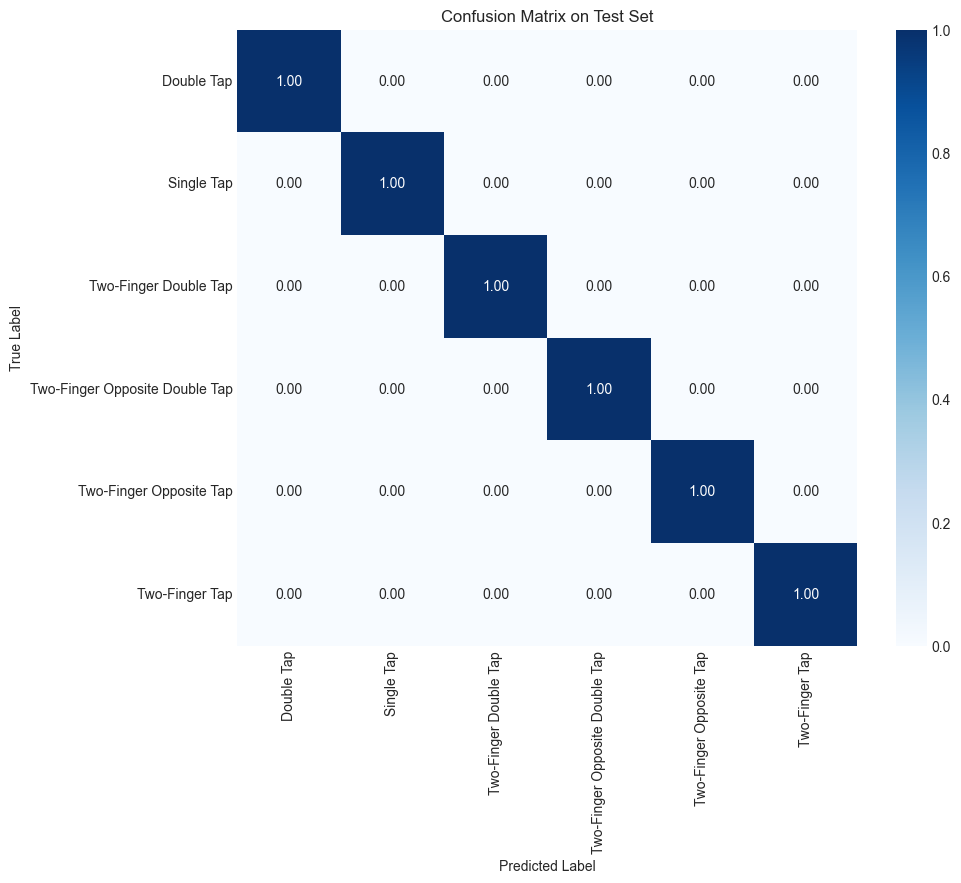

In [42]:
# Draw heatmap of confusion matrix for test set
from sklearn.metrics import confusion_matrix

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

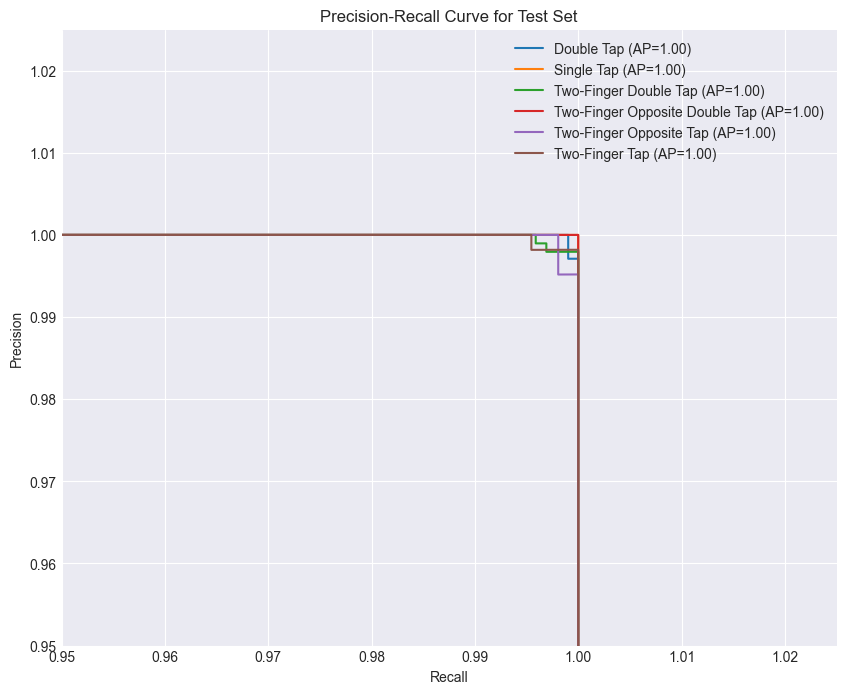

In [43]:
# Draw a precision recall curve for all classes
from sklearn.metrics import precision_recall_curve, average_precision_score
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    y_true_bin = (y_test_true == i).astype(int)
    y_scores = y_test_pred_probs[:, i]
    precision, recall, _ = precision_recall_curve(y_true_bin, y_scores)
    ap = average_precision_score(y_true_bin, y_scores)
    plt.plot(recall, precision, label=f'{le.classes_[i]} (AP={ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Test Set')
plt.ylim(0.95, 1.025)
plt.xlim(0.95, 1.025)
plt.legend()
plt.show()

## Test with Szenarios

In [44]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
-- WHERE is_gesture = 1 and marker_label != 'No Gesture'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None


In [45]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [46]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [47]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df[col] = szenarien_df[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df['motor_angle'] = szenarien_df.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [48]:
# Filter out all rows that dont have a marker_label that ends with "Tap"
# szenarien_df = szenarien_df[szenarien_df["marker_label"].str.endswith("Tap")]
# szenarien_df = szenarien_df.reset_index(drop=True)

In [49]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
dtype: int64

In [50]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
No Gesture                        3235
Tap and Hold                      2479
Spread Swipe                      1723
Single Swipe                      1450
Pinch Swipe                        838
Two-Finger Tap                     553
Two-Finger Double Tap              516
Two-Finger Opposite Double Tap     486
Double Tap                         367
Two-Finger Opposite Tap            315
Name: count, dtype: int64


In [51]:
# Print count of unique session_tasks
print(f"Unique session_task_ids in Szenarien data: {szenarien_df['session_task_id'].nunique()}")

Unique session_task_ids in Szenarien data: 227


In [52]:
# Make feature_df
szenarien_feature_df, szenarien_additional_columns = create_feature_df(szenarien_df)
szenarien_feature_columns = get_column_names(szenarien_additional_columns)

In [53]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)

for sid, sdf in szenarien_feature_df.groupby("session_task_id"):
    X_stream = sdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    streams[sid] = X_stream
    streams_labels[sid] = y_stream

In [54]:
# Print number of streams
print(f"Extracted {len(streams)} streams from Szenarien data.")

Extracted 227 streams from Szenarien data.


In [55]:
# TODO Test if it can identify Non-Gesture via threshold

In [110]:
# max_len = 70
step_size = 10
threshold = 0.0

print(f"Using max_len={max_len}, threshold={threshold} for online prediction.")
touch_indices = [2, 5, 8, 11, 14]  # position columns for touch_1 to touch_5

# For debug purposes draw a graph of the finger positions for each window
def predict_stream_online(X_stream, y_stream):
    did_print = 0
    T, D = X_stream.shape
    preds = []
    pred_times = []
    real_labels = []
    probas = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        window_labels = y_stream[t_start:t_end]
        if not any(label is not None for label in window_labels):
            continue

        # Check if the full window is the same gesture
        unique_labels_in_window = set(label for label in window_labels if label is not None)
        # Check that the label is fully included in the window, by check if the first and last label are none and there is a label contained that is not ending with Tap
        if (window_labels[0] is not None or window_labels[-1] is not None) and len(unique_labels_in_window) != 1:
            continue
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        y_window = y_stream[t_start:t_end]
        window = X_stream[t_start:t_end]

        window_labels = [label for label in y_window if label is not None and label.endswith("Tap")]
        if len(window_labels) == 0:
            continue
        most_common_label = pd.Series(window_labels).mode()[0]

        # Get the correct label for this window (most common label in the window)
        # window_labels = [label for label in y_window if label is not None and label.endswith("Tap")]
        # if len(window_labels) > 0:
        #     most_common_label = pd.Series(window_labels).mode()[0]
        #     if y_window[0] == most_common_label or y_window[-1] == most_common_label:
        #         most_common_label = "No Gesture"
        # else:
        #     most_common_label = "No Gesture"
        real_labels.append(most_common_label)
        
        # --- Model Prediction Logic ---
        window_batch = window[np.newaxis, ...]
        proba = model.predict(window_batch, verbose=0)[0]

        probas.append(proba)

        # print all probabilities for debug with label
        # for cls_idx, class_label in enumerate(le.classes_):
        #     ax.text(t_start, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]) * (cls_idx + 1), 
        #             f"{class_label}: {proba[cls_idx]:.2f}", fontsize=10, verticalalignment='bottom')

        cls_idx = np.argmax(proba)
        conf = proba[cls_idx]
        label = le.classes_[cls_idx] if conf >= threshold else "No Gesture"

        # if label != most_common_label:
        #     print(f"Mismatch at t_start={t_start}: Predicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        #     for cls_idx_debug, class_label in enumerate(le.classes_):
        #         print(f"  {class_label}: {proba[cls_idx_debug]:.4f}")

        #     # Draw a graph of all finger positions
        #     plt.figure(figsize=(15, 10))
        #     time_axis = np.arange(window.shape[0])
        #     for touch_num in range(2, 6):
        #         plt.scatter(
        #             time_axis, 
        #             window[:, feature_columns.index(f"dist_1_{touch_num}")], 
        #             label=f"Touch {touch_num}", 
        #             alpha=0.6
        #         )
        #     plt.xlabel("Time Step")
        #     plt.ylabel("Touch Position")
        #     plt.title(f"Touch Positions Over Time for Window starting at {t_start}\nPredicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        #     plt.legend()
        #     plt.show()
        #     return
        # else:
        #     print(f"Match at t_start={t_start}: Predicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        
        # Add text info to the plot itself
        # ax.text(t_start, ax.get_ylim()[1], f"Pred: {label} ({conf:.2f})", 
        #         fontsize=12, fontweight='bold', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

        preds.append(label)
        pred_times.append(t_start)

        # did_print += 1
        # if did_print >= 5:
        #     break

    # plt.tight_layout()
    # plt.show()
    return np.array(preds), np.array(pred_times), np.array(real_labels), np.array(probas)


Using max_len=55, threshold=0.0 for online prediction.


In [111]:
from sklearn.metrics import confusion_matrix, classification_report

all_true = []
all_pred = []
all_probas = []

# print streams keys
did_it = 0
for sid, X_stream in streams.items():
    did_it += 1
    y_stream = streams_labels[sid] 
    preds, pred_times, real_labels, probas = predict_stream_online(X_stream, y_stream)

    all_true.extend(real_labels)
    all_pred.extend(preds)
    all_probas.extend(probas)

    # Print y_stream for those that are not none
    # print(f"True labels for stream {sid}:")
    # for i in range(len(y_stream)):
    #     if y_stream[i] is not None:
    #         print(f"  Index {i}: {y_stream[i]}")

    # if did_it >= 1:
    #     break


In [112]:
# Print unique all_true and all_pred labels
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_probas = np.array(all_probas)
# Replace None with "No Gesture" in all_true
all_true = np.array([label if label is not None and label != 'No Gesture' else "No Gesture" for label in all_true])
unique_true_labels = np.unique(all_true)
unique_pred_labels = np.unique(all_pred)
print(f"Unique true labels: ({len(unique_true_labels)}) {unique_true_labels}")
print(f"Unique predicted labels: ({len(unique_pred_labels)}) {unique_pred_labels}")

Unique true labels: (5) ['Double Tap' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Unique predicted labels: (6) ['Double Tap' 'Single Tap' 'Two-Finger Double Tap'
 'Two-Finger Opposite Double Tap' 'Two-Finger Opposite Tap'
 'Two-Finger Tap']


                                precision    recall  f1-score   support

                    Double Tap       0.45      0.23      0.31        95
                    Single Tap       0.00      0.00      0.00         0
         Two-Finger Double Tap       0.28      0.60      0.38       130
Two-Finger Opposite Double Tap       0.48      0.35      0.41        79
       Two-Finger Opposite Tap       0.35      0.43      0.39        67
                Two-Finger Tap       0.56      0.24      0.34       200

                      accuracy                           0.36       571
                     macro avg       0.35      0.31      0.30       571
                  weighted avg       0.44      0.36      0.36       571



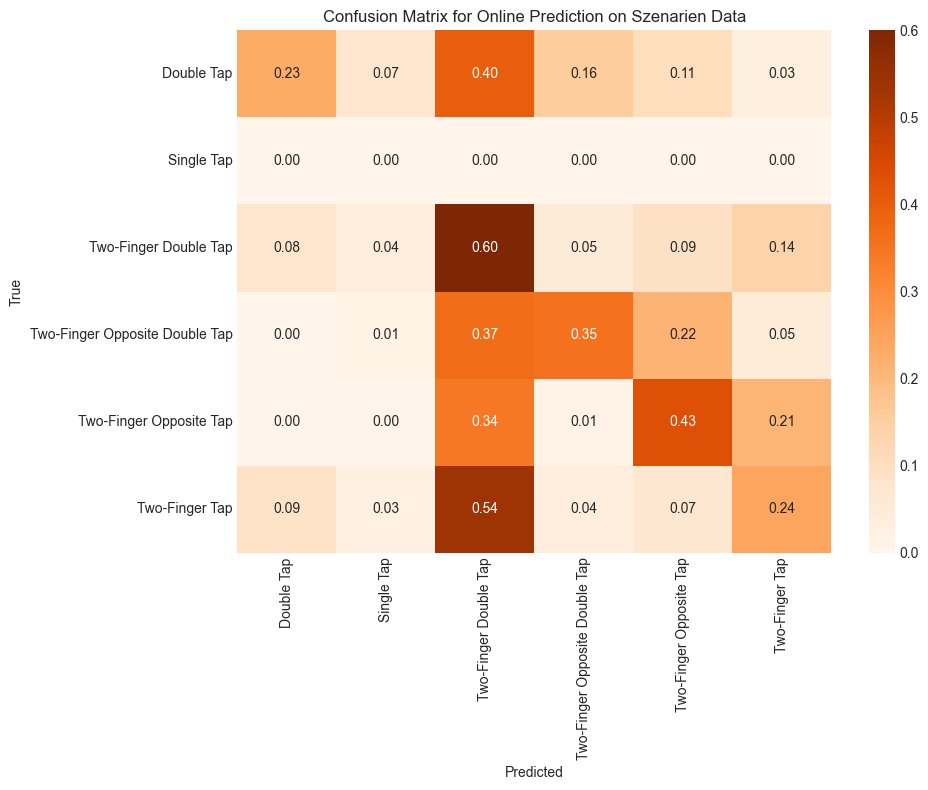

In [113]:
# Optionally restrict to known classes
# map string labels -> indices with same LabelEncoder if classes match
# extended_classes = np.append(le.classes_, "No Gesture")

# le_ext = LabelEncoder()
# le_ext.fit(extended_classes)
le_ext = le

y_true_int = le_ext.transform(all_true)
y_pred_int = le_ext.transform(all_pred)
# y_true_int = le.transform(all_true)           # if marker labels use same names
# y_pred_int = le.transform(all_pred)

used_labels = np.unique(np.concatenate([y_true_int, y_pred_int]))
used_target_names = le_ext.inverse_transform(used_labels)
print(
    classification_report(
        y_true_int,
        y_pred_int,
        labels=used_labels,
        target_names=used_target_names
    )
)

cm = confusion_matrix(y_true_int, y_pred_int, labels=range(len(le_ext.classes_)))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le_ext.classes_,
    yticklabels=le_ext.classes_,
    cmap="Oranges"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Online Prediction on Szenarien Data")
plt.tight_layout()
plt.show()


In [114]:
# Print the top-k stats
from collections import defaultdict

def top_k_classification_report(
    y_true,
    y_proba,
    k=3,
    class_names=None
):
    n_classes = y_proba.shape[1]
    top_k_preds = np.argsort(y_proba, axis=1)[:, -k:]

    support = defaultdict(int)
    tp = defaultdict(int)
    pred_count = defaultdict(int)

    for i, true_cls in enumerate(y_true):
        support[true_cls] += 1

        for pred_cls in top_k_preds[i]:
            pred_count[pred_cls] += 1
            if pred_cls == true_cls:
                tp[pred_cls] += 1

    rows = []

    for cls in range(n_classes):
        sup = support[cls]
        if sup == 0:
            precision = recall = f1 = 0.0
        else:
            precision = tp[cls] / pred_count[cls] if pred_count[cls] > 0 else 0.0
            recall = tp[cls] / sup
            f1 = (
                2 * precision * recall / (precision + recall)
                if (precision + recall) > 0
                else 0.0
            )

        name = class_names[cls] if class_names is not None else str(cls)
        rows.append((name, precision, recall, f1, sup))

    return rows

In [115]:
top1 = top_k_classification_report(
    y_true_int,
    all_probas,
    k=1,
    class_names=le_ext.classes_
)

top3 = top_k_classification_report(
    y_true_int,
    all_probas,
    k=2,
    class_names=le_ext.classes_
)

print(
    f"{'Class':35s}"
    f"{'P@1':>6s}{'R@1':>6s}{'F1@1':>7s} | "
    f"{'P@2':>6s}{'R@2':>6s}{'F1@2':>7s}{'Sup':>6s}"
)

for (c1, p1, r1, f1, sup), (_, p3, r3, f3, _) in zip(top1, top3):
    print(
        f"{c1:35s}"
        f"{p1:6.2f}{r1:6.2f}{f1:7.2f} | "
        f"{p3:6.2f}{r3:6.2f}{f3:7.2f}{sup:6d}"
    )

Class                                 P@1   R@1   F1@1 |    P@2   R@2   F1@2   Sup
Double Tap                           0.45  0.23   0.31 |   0.42  0.34   0.37    95
Single Tap                           0.00  0.00   0.00 |   0.00  0.00   0.00     0
Two-Finger Double Tap                0.28  0.60   0.38 |   0.25  0.74   0.37   130
Two-Finger Opposite Double Tap       0.48  0.35   0.41 |   0.22  0.73   0.34    79
Two-Finger Opposite Tap              0.35  0.43   0.39 |   0.27  0.52   0.36    67
Two-Finger Tap                       0.56  0.24   0.34 |   0.39  0.45   0.41   200


In [116]:
# Test with szenarios, but give a whole marker_label group at once to check if the classification would work with the correct windowing strategy

# Put all group_ids in windows
windows = []
window_lables = []
meta_data = []
for gid, gdf in szenarien_feature_df.groupby("group_id"):
    # ignore if the marker_label is "No Gesture" or None
    if gdf["marker_label"].iloc[0] is None or not gdf["marker_label"].iloc[0].endswith("Tap"):
        continue
    X_window = gdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    windows.append(X_window)
    marker_label = gdf["marker_label"].iloc[0]
    window_lables.append(marker_label if marker_label is not None and marker_label.endswith("Tap") else "No Gesture")
    meta_data.append({
        "session_task_id": gdf["session_task_id"].iloc[0],
        "participant_id": gdf["participant_id"].iloc[0],
        "group_id": gid
    })

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 82 windows from Szenarien data for group_id prediction.


In [117]:
# Draw graphs of the first 5 windows and their finger positions
# for w_idx in range(min(5, len(windows))):
#     plt.figure(figsize=(15, 10))
#     window = windows[w_idx]

#     # Print session_task_id for window
#     meta = window_meta[w_idx]
#     print(f"Window {w_idx} - Session Task ID: {meta['session_task_id']}, Participant ID: {meta['participant_id']}, Group ID: {meta['group_id']}")    
    
#     prediction = model.predict(window[np.newaxis, ...], verbose=0)[0]
#     cls_idx = np.argmax(prediction)
#     conf = prediction[cls_idx]
#     predicted_label = le.classes_[cls_idx]

#     # Print all prediction confidences that are above 0.05
#     print(f"Window {w_idx} Prediction Confidences:")
#     for cls_i, class_label in enumerate(le.classes_):
#         prob = prediction[cls_i]
#         if prob >= 0.05:
#             print(f"  {class_label}: {prob:.2f}")

#     label = window_lables[w_idx]
#     for touch_num in range(1, 6):
#         # Only get indices that have non-zero positions
#         pressure_col_idx = touch_indices[touch_num - 1] + 1  # pressure column index
#         touch_indices_cleaned = np.where(window[:, pressure_col_idx] > 0)[0]
#         plt.scatter(
#             touch_indices_cleaned, 
#             window[touch_indices_cleaned, touch_indices[touch_num - 1]], 
#             label=f"Touch {touch_num}", 
#             alpha=0.6
#         )
#     plt.xlabel("Frame Index")
#     plt.ylabel("Touch Position")
#     plt.title(f"Touch Positions Over Time for Window {w_idx} (Label: {label}) - Predicted: {predicted_label} ({conf:.2f})")
#     plt.legend()
#     plt.show()

In [118]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=11, max=73
Window label counts:
  Two-Finger Tap: 29
  Two-Finger Double Tap: 15
  Two-Finger Opposite Double Tap: 14
  Two-Finger Opposite Tap: 13
  Double Tap: 11


In [119]:
# Predict each window
all_window_true = []
all_window_pred = []
all_window_proba = []

for X_window, true_label in zip(windows, window_lables):
    X_batch = X_window[np.newaxis, ...]  # (1, max_len, D)
    proba = model.predict(X_batch, verbose=0)[0]
    
    all_window_proba.append(proba)

    cls_idx = np.argmax(proba)
    conf = proba[cls_idx]
    pred_label = le.classes_[cls_idx] if conf >= threshold else "No Gesture"

    all_window_true.append(true_label)
    all_window_pred.append(pred_label)
# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
all_window_proba = np.array(all_window_proba)
unique_window_true_labels = np.unique(all_window_true)
unique_window_pred_labels = np.unique(all_window_pred)
print(f"Unique true window labels: ({len(unique_window_true_labels)}) {unique_window_true_labels}")
print(f"Unique predicted window labels: ({len(unique_window_pred_labels)}) {unique_window_pred_labels}")

Unique true window labels: (5) ['Double Tap' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Unique predicted window labels: (5) ['Double Tap' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']


                                precision    recall  f1-score   support

                    Double Tap       1.00      0.27      0.43        11
         Two-Finger Double Tap       0.86      0.80      0.83        15
Two-Finger Opposite Double Tap       0.64      1.00      0.78        14
       Two-Finger Opposite Tap       0.71      0.92      0.80        13
                Two-Finger Tap       0.92      0.83      0.87        29

                      accuracy                           0.79        82
                     macro avg       0.82      0.76      0.74        82
                  weighted avg       0.84      0.79      0.78        82



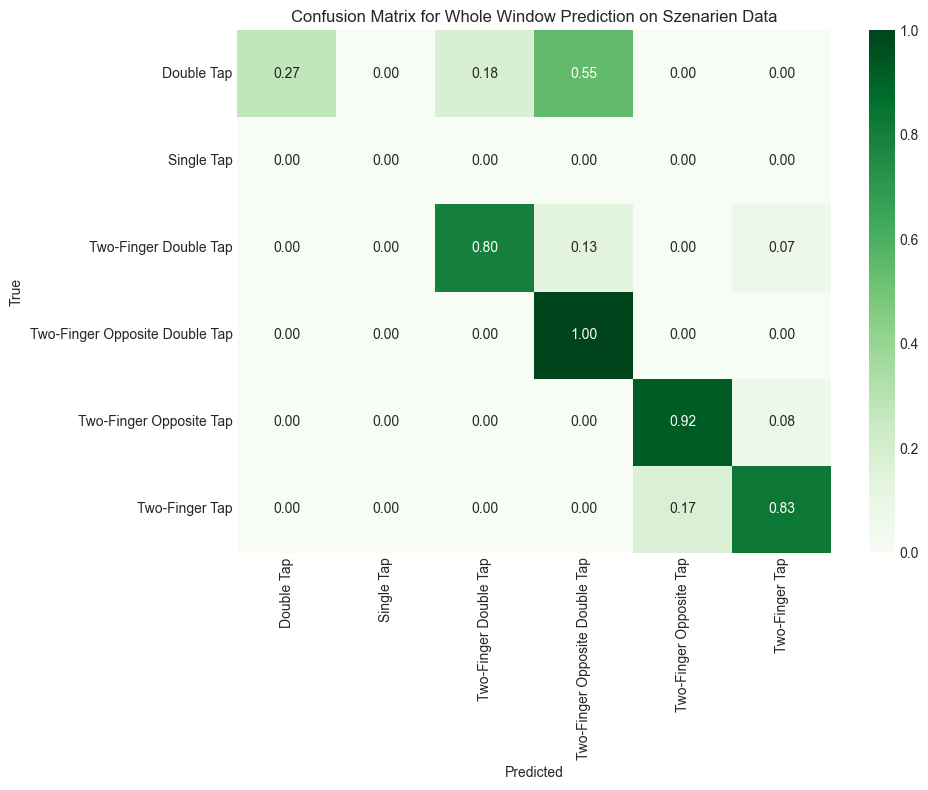

In [120]:
# Print confusion matrix and classification report for window predictions
y_window_true_int = le_ext.transform(all_window_true)           # if marker labels use same names
y_window_pred_int = le_ext.transform(all_window_pred)

used_labels_window = np.unique(np.concatenate([y_window_true_int, y_window_pred_int]))
used_target_names_window = le_ext.inverse_transform(used_labels_window)
print(
    classification_report(
        y_window_true_int,
        y_window_pred_int,
        labels=used_labels_window,
        target_names=used_target_names_window
    )
)

cm_window = confusion_matrix(y_window_true_int, y_window_pred_int, labels=range(len(le_ext.classes_)))
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1)[:, np.newaxis]
cm_window_norm = np.nan_to_num(cm_window_norm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le_ext.classes_,
    yticklabels=le_ext.classes_,
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Whole Window Prediction on Szenarien Data")
plt.tight_layout()
plt.show()

In [121]:
top1 = top_k_classification_report(
    y_window_true_int,
    all_window_proba,
    k=1,
    class_names=le_ext.classes_
)

top3 = top_k_classification_report(
    y_window_true_int,
    all_window_proba,
    k=2,
    class_names=le_ext.classes_
)

print(
    f"{'Class':35s}"
    f"{'P@1':>6s}{'R@1':>6s}{'F1@1':>7s} | "
    f"{'P@2':>6s}{'R@2':>6s}{'F1@2':>7s}{'Sup':>6s}"
)

for (c1, p1, r1, f1, sup), (_, p3, r3, f3, _) in zip(top1, top3):
    print(
        f"{c1:35s}"
        f"{p1:6.2f}{r1:6.2f}{f1:7.2f} | "
        f"{p3:6.2f}{r3:6.2f}{f3:7.2f}{sup:6d}"
    )

Class                                 P@1   R@1   F1@1 |    P@2   R@2   F1@2   Sup
Double Tap                           1.00  0.27   0.43 |   0.67  0.36   0.47    11
Single Tap                           0.00  0.00   0.00 |   0.00  0.00   0.00     0
Two-Finger Double Tap                0.86  0.80   0.83 |   0.38  0.93   0.54    15
Two-Finger Opposite Double Tap       0.64  1.00   0.78 |   0.40  1.00   0.57    14
Two-Finger Opposite Tap              0.71  0.92   0.80 |   0.59  1.00   0.74    13
Two-Finger Tap                       0.92  0.83   0.87 |   0.69  1.00   0.82    29


In [122]:
import winsound

winsound.MessageBeep()  # system default sound